In [1]:
import numpy as np
import random as rn
import matplotlib.pyplot as plt
import math
from matplotlib.patches import Polygon as PolyPatch, Wedge, FancyArrow
import os, json

# Custom Settings
from convex_map import generate_map
from heatmap_animation import generate_heatmap


In [2]:
# Operation Map Visualization
def _bounce_angle(theta0: float, bound_plus: float, bound_minus: float, panspeed: float, t: float) -> float:
    """
    Bounce-pan angle inside [theta0+bound_minus, theta0+bound_plus] at time t.
    Angles are radians; panspeed is rad per unit time.
    """
    lo = theta0 + float(bound_minus)
    hi = theta0 + float(bound_plus)
    if lo > hi:
        lo, hi = hi, lo
    span = hi - lo
    if span <= 1e-12 or abs(panspeed) <= 1e-12:
        return theta0
    raw = theta0 + panspeed * t
    period = 2.0 * span
    off = (raw - lo) % period
    return (lo + off) if (off <= span) else (hi - (off - span))

def visualize_map_at_time(map_in, cam_dict, t: float, sensor_alpha: float = 0.5, ax=None):
    """
    Visualize the operation map at time t using your schema.

    Args:
        map_in: dict with 'st': {'size': [xmin,xmax,ymin,ymax], 'n': int, '0': poly0, ...}
        cam_dict: dict with 'n', 'x', 'y', and 'spec' fields:
            - spec['init_angle'] : list of radians
            - spec['bound']      : array-like shape (n, 2) = [ [ +max, -max ], ... ]
            - spec['fov']        : [ half_angle_rad, range ]
            - spec['cam_time']   : [ cam_period, cam_increment ]  (not required here)
            - spec['panspeed']   : list of rad/time
        t: time (same units as your panspeed / cam_time increment)
        sensor_alpha: alpha for the green FOV wedges
        ax: optional matplotlib Axes; if None, a new figure/axes is created

    Returns:
        fig, ax
    """
    # ---- Static map bounds & buildings ----
    st = map_in["st"]
    size = np.array(st["size"], dtype=float)   # [xmin, xmax, ymin, ymax]
    xmin, xmax, ymin, ymax = size

    buildings = []
    for i in range(st["n"]):
        poly = np.array(st[str(i)], dtype=float)
        buildings.append(poly)

    # ---- Cameras & spec ----
    cx = np.array(cam_dict["x"], dtype=float)
    cy = np.array(cam_dict["y"], dtype=float)
    spec = cam_dict["spec"]
    init_angles = np.array(spec["init_angle"], dtype=float)          # radians
    bound_arr = np.array(spec["bound"], dtype=float)                 # (n,2) = [+max, -max]
    fov_half = float(spec["fov"][0])                                 # radians
    fov_range = float(spec["fov"][1])                                # map units
    panspeeds = np.array(spec["panspeed"], dtype=float)              # rad/time

    # Compute facing angles at time t with bounce pan
    facings = np.array([
        _bounce_angle(init_angles[i], bound_arr[i,0], bound_arr[i,1], panspeeds[i], t)
        for i in range(len(cx))
    ], dtype=float)

    # ---- Plot ----
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    else:
        fig = ax.figure

    # Buildings: black
    for poly in buildings:
        ax.add_patch(PolyPatch(poly, closed=True, facecolor="black", edgecolor="black", alpha=1.0))

    # Sensors: green circles
    ax.scatter(cx, cy, s=36, c="green", marker="o", zorder=3, label="sensors")

    # FOV wedges: green with alpha
    for i in range(len(cx)):
        theta_deg = math.degrees(facings[i])
        wedge = Wedge(
            center=(cx[i], cy[i]),
            r=fov_range,
            theta1=theta_deg - math.degrees(fov_half),
            theta2=theta_deg + math.degrees(fov_half),
            facecolor="green",
            edgecolor=None,
            alpha=float(sensor_alpha),
            zorder=2
        )
        ax.add_patch(wedge)

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.3)
    ax.set_title(f"Operation Map @ t = {t:.2f}")
    return fig, ax


In [3]:
from matplotlib.animation import FuncAnimation, writers

def _bounce_angle(theta0: float, bound_plus: float, bound_minus: float, panspeed: float, t: float) -> float:
    """Bounce-pan angle inside [theta0+bound_minus, theta0+bound_plus] at time t (radians)."""
    lo = theta0 + float(bound_minus)
    hi = theta0 + float(bound_plus)
    if lo > hi:
        lo, hi = hi, lo
    span = hi - lo
    if span <= 1e-12 or abs(panspeed) <= 1e-12:
        return theta0
    raw = theta0 + panspeed * t
    period = 2.0 * span
    off = (raw - lo) % period
    return (lo + off) if (off <= span) else (hi - (off - span))

def animate_camera_rotation(
    map_in: dict,
    cam_dict: dict,
    t_start: float = 0.0,
    t_end: float = 100.0,
    frame_interval: float = None,  # interval of frames
    dt_override: float = None,     # set to e.g. 0.1 for smoother playback; default uses spec['cam_time'][1]
    sensor_alpha: float = 0.5,
    save_path: str = None,          # e.g., "cams.mp4" or "cams.gif"
    desired_fps: int=24
):
    """
    Animate camera rotation over time using your map_in/cam_dict schema.

    Args:
        map_in: dict with 'st': {'size':[xmin,xmax,ymin,ymax], 'n': int, '0': poly0, ...}
        cam_dict: dict with 'n','x','y','spec' (init_angle, bound, fov, cam_time, panspeed)
        t_start, t_end: time window (seconds, or whatever units your panspeed uses)
        dt_override: if provided, overrides spec['cam_time'][1] for animation step
        sensor_alpha: FOV wedge alpha
        save_path: optional .mp4 or .gif

    Returns:
        (fig, anim)
    """
    # --- Static map & buildings ---
    st = map_in["st"]
    size = np.array(st["size"], dtype=float)  # [xmin, xmax, ymin, ymax]
    xmin, xmax, ymin, ymax = size
    buildings = [np.array(st[str(i)], dtype=float) for i in range(int(st["n"]))]

    # --- Cameras & spec ---
    cx = np.array(cam_dict["x"], dtype=float)
    cy = np.array(cam_dict["y"], dtype=float)
    spec = cam_dict["spec"]
    init_angles = np.array(spec["init_angle"], dtype=float)
    bound_arr = np.array(spec["bound"], dtype=float)     # shape (n,2): [+max, -max]
    fov_half = float(spec["fov"][0])
    fov_range = float(spec["fov"][1])
    cam_period, cam_increment = int(spec["cam_time"][0]), float(spec["cam_time"][1])
    panspeeds = np.array(spec["panspeed"], dtype=float)

    dt = float(dt_override) if dt_override is not None else cam_increment
    t_vals = np.arange(t_start, t_end + 1e-9, dt)
    n_frames = len(t_vals)

    # --- Figure & static artists ---
    fig, ax = plt.subplots(figsize=(6, 6))
    # Buildings: black
    for poly in buildings:
        ax.add_patch(PolyPatch(poly, closed=True, facecolor="black", edgecolor="black", alpha=1.0))

    # Sensors: green circles
    ax.scatter(cx, cy, s=36, c="green", marker="o", zorder=3, label="sensors")

    # FOV wedges (one per sensor; we will update their angles)
    wedges: list[Wedge] = []
    for i in range(len(cx)):
        # initialize at t = t_start
        facing = _bounce_angle(init_angles[i], bound_arr[i,0], bound_arr[i,1], panspeeds[i], t_vals[0])
        theta_deg = math.degrees(facing)
        w = Wedge(center=(cx[i], cy[i]),
                  r=fov_range,
                  theta1=theta_deg - math.degrees(fov_half),
                  theta2=theta_deg + math.degrees(fov_half),
                  facecolor="green",
                  edgecolor=None,
                  alpha=float(sensor_alpha),
                  zorder=2)
        ax.add_patch(w)
        wedges.append(w)

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.3)
    # title = ax.set_title(f"Camera Rotation | t = {t_vals[0]:.2f}")

    # --- Update function ---
    def update(frame_idx: int):
        t = t_vals[frame_idx]
        for i, w in enumerate(wedges):
            facing = _bounce_angle(init_angles[i], bound_arr[i,0], bound_arr[i,1], panspeeds[i], t)
            theta_deg = math.degrees(facing)
            w.set_theta1(theta_deg - math.degrees(fov_half))
            w.set_theta2(theta_deg + math.degrees(fov_half))
        # title.set_text(f"Camera Rotation | t = {t:.2f}")
        return wedges

    anim = FuncAnimation(fig, update, frames=n_frames, blit=True, interval=frame_interval)

    # Optional save
    if save_path:
        ext = save_path.lower().split(".")[-1]
        if ext == "mp4":
            try:
                Writer = writers["ffmpeg"]
                writer = Writer(fps=desired_fps, metadata=dict(artist="cams"), bitrate=2000)
                anim.save(save_path, writer=writer, dpi=150)
            except Exception as exc:
                print("FFMPEG not available or save failed:", exc)
        elif ext == "gif":
            try:
                anim.save(save_path, writer="pillow", dpi=150)
            except Exception as exc:
                print("GIF save failed:", exc)
        else:
            print("Unknown extension; not saved. Use .mp4 or .gif.")

    return fig, anim


In [35]:
# Run to Generate Map for Operation
map_in, cam_dict = generate_map(
    map_size = (100, 100),
    num_buildings = 5,
    num_sensors = 8,
    fov_half_rad = np.deg2rad(25),
    max_range = 20,
    panspeed_range = (np.deg2rad(-5), np.deg2rad(5)),
    cam_period = 200,
    cam_increment = 0.2,
    rng_seed = 21,
    balanced_sensors = False     # spread sensors across buildings
)


(<Figure size 600x600 with 1 Axes>,
 <AxesSubplot:title={'center':'Operation Map @ t = 0.00'}>)

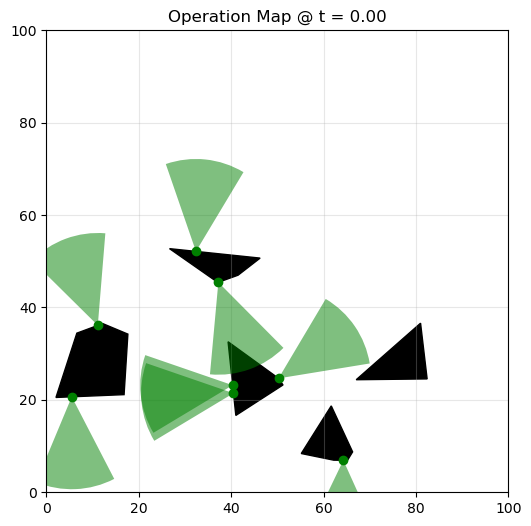

In [37]:
# Plot Map for Sanity Check
visualize_map_at_time(map_in, cam_dict, t=0, sensor_alpha=0.5)

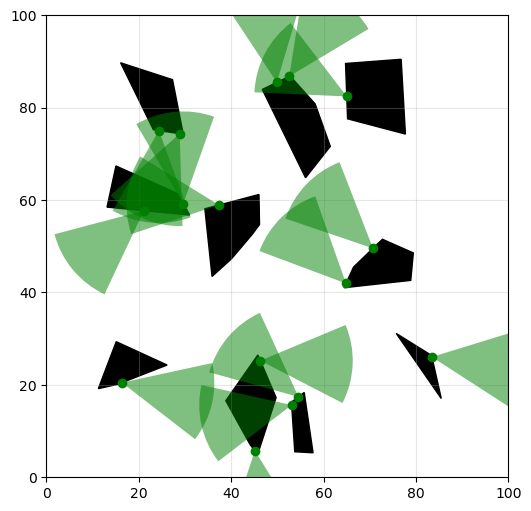

In [ ]:
# Animate from 0 to 100 s using your cam_time increment
# fig, anim = animate_camera_rotation(map_in, cam_dict, t_start=0.0, t_end=100.0, sensor_alpha=0.5)

# …or smoother playback with a smaller dt:
# fig, anim = animate_camera_rotation(map_in, cam_dict, t_start=0.0, t_end=100.0, dt_override=0.1, sensor_alpha=0.5)

# …or save it:
fig, anim = animate_camera_rotation(map_in, cam_dict, 0.0, 100.0, frame_interval=1, save_path="cams.mp4", desired_fps=50)


In [11]:
def make_json_serializable(obj):
    """
    Recursively convert numpy arrays in obj to lists,
    so it can be JSON-serialized.
    """
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, dict):
        return {k: make_json_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, (list, tuple)):
        return [make_json_serializable(v) for v in obj]
    else:
        return obj

In [38]:
# Setup for STP-RRT*
x0 = [20, 0, 0]
xf = [80, 80, 1000]
vmax = 10

stp_rrt_setup = {}
stp_rrt_setup['x0'] = x0
stp_rrt_setup['xf'] = xf
stp_rrt_setup['vmax'] = vmax

In [39]:
# Output into JSON file
# Full path to the file
file_path1 = os.path.join("json", "operation_map.json")
file_path2 = os.path.join("json", "defender_info.json")
file_path3 = os.path.join("json", "stp_rrt_setup.json")

# Write JSON file into that folder
with open(file_path1, "w") as f:
    json.dump(make_json_serializable(map_in), f, indent=4)

with open(file_path2, "w") as f:
    json.dump(make_json_serializable(cam_dict), f, indent=4)

with open(file_path3, "w") as f:
    json.dump(stp_rrt_setup, f, indent=4)